In [278]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.stats as st

Генерация таблицы  Electrician_meter (с информацией о электросчечиках)


Описание столбца (название столбца):

Номер электросчечика (number) - int - Primary Key\
Название счетчика (name) - str\
Количество фаз: однофазный/трехфазный (number_phases) - str\
Номинальный ток, A (current) - int\
Номинальное напряжение, В (voltage) - int\
Год производства (year_production) - int\
Межповерочный интервал (intervaliment_interval) - int

In [279]:
# Генерация данных
numbers = np.arange(1, 10 + 1, dtype=int)
names = ['Энергомера CE101', 'Меркурий 201.7', 'АГАТ 1-1', 'АГАТ 2-32', 'Меркурий АМ-01', 'Меркурий AR 03 R', 'Меркурий 350', 'Меркурий 231 AMш', 'СА4-ИП2', 'Меркурий 231 АМ-01']
numbers_phases = ['Однофазный', 'Однофазный', 'Однофазный', 'Однофазный', 'Однофазный', 'Трехфазный', 'Трехфазный', 'Трехфазный', 'Трехфазный', 'Трехфазный']
currents = [5, 10, 5, 5, 5, 7.5, 10, 7.5, 10, 5]
voltages = [220, 230, 230, 220, 230, 400, 380, 400, 380, 380]
years_production = [2020, 2012, 2012, 2024, 2008, 2019, 2023, 2012, 2008, 2020]
verification_intervals = [16, 12, 16, 16, 10, 10, 16, 12, 16, 10]

In [280]:
# Создание DataFrame
Electrician_meter = pd.DataFrame({'number': numbers,
                                  'name': names,
                                  'numbers_phase': numbers_phases,
                                  'current': currents,
                                  'voltage': voltages,
                                  'year_production': years_production,
                                  'verification_interval': verification_intervals
                                })

Electrician_meter

,number,name,numbers_phase,current,voltage,year_production,verification_interval
0,1,Энергомера CE101,Однофазный,5.0,220,2020,16
1,2,Меркурий 201.7,Однофазный,10.0,230,2012,12
2,3,АГАТ 1-1,Однофазный,5.0,230,2012,16
3,4,АГАТ 2-32,Однофазный,5.0,220,2024,16
4,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10
5,6,Меркурий AR 03 R,Трехфазный,7.5,400,2019,10
6,7,Меркурий 350,Трехфазный,10.0,380,2023,16
7,8,Меркурий 231 AMш,Трехфазный,7.5,400,2012,12
8,9,СА4-ИП2,Трехфазный,10.0,380,2008,16
9,10,Меркурий 231 АМ-01,Трехфазный,5.0,380,2020,10


Генерация таблицы Users_Rostov_on_Don (с информацией о пользователях в Ростове-на-Дону) с 2.000 пользователями


Описание столбца (название столбца):

Номер пользователя (user) - int - Primary Key\
Название улицы / проспекта  (street) - str\
Номер дома (house) - str\
Тип электросчетчика (electrician_meter_type) - int\
Дата подлючение к сети (date_connection) - date


In [281]:
# Генерация данных
num_users = 5000
streets = ['Волкова', 'Космонавтов', 'Орбитальная', 'Ларина', 'Борко', 'Комарова', 'Добровольского', 'Михаила Нагибина', 'Ленина', 'Капустина']
streets_houses = [100, 150, 150, 50, 50, 50, 100, 150, 150, 100] # Количесвто домов на улице
electrician_meter_types = np.arange(1, 10 + 1, dtype=int)
date_range = pd.date_range(start=datetime(2010, 1, 1), end=datetime(2024, 9, 30), freq='D')

In [282]:
# Создание DataFrame
user = np.arange(1, num_users + 1, dtype=int)
street = np.random.choice(streets, num_users, p=np.array(streets_houses) / np.sum(streets_houses))
house = np.random.randint(1, 100, num_users).astype(str)
date_connection = pd.to_datetime(np.random.choice(date_range, num_users))

In [283]:
all_houses = []
for ind, i in enumerate(streets):
    houses = np.arange(1, streets_houses[ind] + 1).astype(str)
    all_houses.append(houses)

house_list = []
for i, street_name in enumerate(street):
    ind = streets.index(street_name)
    house = np.random.choice(all_houses[ind], 1)[0]
    house_list.append(house)

In [284]:
electrician_meter_type = []
# Проверка, чтобы на дату установки не был установлен счетчик, который еще не вышел
for i in user:
    electrician_meter_type.append(np.random.choice(Electrician_meter[Electrician_meter.year_production <= date_connection[i-1].year].number.to_list()))

In [285]:
Users_Rostov_on_Don = pd.DataFrame({'user': user,
                                    'street': street,
                                    'house': house_list,
                                    'electrician_meter_type': electrician_meter_type,
                                    'date_connection': date_connection
                                    })

Users_Rostov_on_Don

,user,street,house,electrician_meter_type,date_connection
0,1,Добровольского,76,6,2023-09-28
1,2,Волкова,60,10,2021-03-04
2,3,Борко,8,6,2019-12-20
3,4,Ларина,15,3,2020-01-07
4,5,Михаила Нагибина,146,8,2013-09-05
...,...,...,...,...,...
4995,4996,Добровольского,65,5,2011-07-14
4996,4997,Ленина,147,2,2015-01-15
4997,4998,Михаила Нагибина,97,5,2010-08-12
4998,4999,Ленина,83,8,2014-03-11


Генерация таблицы  Energy_consumption (с информацией о потреблении электроэнергии пользователями по часам за последние 3 месяца)


Описание столбца (название столбца):

Номер пользователя (user) - int - Primary Key

Время потребления (time) - datetime - Primary Key

Потребленная мощность (power) - float

In [286]:
# Генерация данных
datetime_range = pd.date_range(start=datetime(2024, 12, 1), end=datetime(2024, 12, 31), freq='h')

all_data = []

user_base_powers = np.random.normal(loc=1.5, scale=0.5, size=num_users) # Базовое потребеление для каждого пользователя

user_type = np.random.choice([0,1], size = num_users, p = [0.9,0.1]) # 10% распределение по другому

x = np.arange(0, 24, 1)

peak_distribution = st.norm.pdf(x, loc=18, scale=3)
peak_distribution = peak_distribution / np.max(peak_distribution)

for user in range(1, num_users + 1):
    for time in datetime_range:
        hour = time.hour
        base_power = user_base_powers[user - 1] # Получаем базовое значение
        deviation = 0

        if 22 <= hour or hour < 6:
            deviation = np.random.normal(loc=0, scale=0.3)
            power = base_power * np.random.uniform(0.1, 0.5) + deviation

            if np.random.choice([True, False], p = [0.2, 0.8]):
                power *= np.random.uniform(0.1, 0.5) 

        elif 6 <= hour < 10:
            deviation = np.random.normal(loc=0, scale=0.3)
            power = base_power * (0.7 + (hour - 6) / 2) + deviation

            if np.random.choice([True, False], p = [0.1, 0.9]):
                power *= np.random.uniform(0.5, 2) 

        elif 10 <= hour < 18:
            deviation = np.random.normal(loc=0, scale=0.4)
            power = base_power + deviation

            if np.random.choice([True, False], p = [0.1, 0.9]):
                power *= np.random.uniform(0.2, 0.5)

        elif 18 <= hour < 22:
            deviation = np.random.normal(loc=0, scale=0.5)
            power = base_power* (0.2 + (22 - hour)/4) + deviation
            
            if np.random.choice([True, False], p = [0.1, 0.9]):
                power *= np.random.uniform(0.7, 2)

        if user_type[user - 1] == 1:
            power = base_power+deviation

        power *= (0.5 + 1.5 * peak_distribution[hour])# Применяем коэф

        if power < 0:
            power = 0

        all_data.append([user, time, power])
    
Energy_consumption = pd.DataFrame(all_data, columns = ['user','time','power'])


In [287]:
Energy_consumption

,user,time,power
0,1,2024-12-01 00:00:00,0.025937
1,1,2024-12-01 01:00:00,0.292168
2,1,2024-12-01 02:00:00,0.406736
3,1,2024-12-01 03:00:00,0.178273
4,1,2024-12-01 04:00:00,0.184987
...,...,...,...
3604995,5000,2024-12-30 20:00:00,1.930979
3604996,5000,2024-12-30 21:00:00,0.000000
3604997,5000,2024-12-30 22:00:00,1.580093
3604998,5000,2024-12-30 23:00:00,0.308156


In [288]:
Users_consumption = pd.merge(Users_Rostov_on_Don, Energy_consumption, on = 'user', how = 'left')
Users_consumption

,user,street,house,electrician_meter_type,date_connection,time,power
0,1,Добровольского,76,6,2023-09-28,2024-12-01 00:00:00,0.025937
1,1,Добровольского,76,6,2023-09-28,2024-12-01 01:00:00,0.292168
2,1,Добровольского,76,6,2023-09-28,2024-12-01 02:00:00,0.406736
3,1,Добровольского,76,6,2023-09-28,2024-12-01 03:00:00,0.178273
4,1,Добровольского,76,6,2023-09-28,2024-12-01 04:00:00,0.184987
...,...,...,...,...,...,...,...
3604995,5000,Михаила Нагибина,111,3,2012-08-09,2024-12-30 20:00:00,1.930979
3604996,5000,Михаила Нагибина,111,3,2012-08-09,2024-12-30 21:00:00,0.000000
3604997,5000,Михаила Нагибина,111,3,2012-08-09,2024-12-30 22:00:00,1.580093
3604998,5000,Михаила Нагибина,111,3,2012-08-09,2024-12-30 23:00:00,0.308156


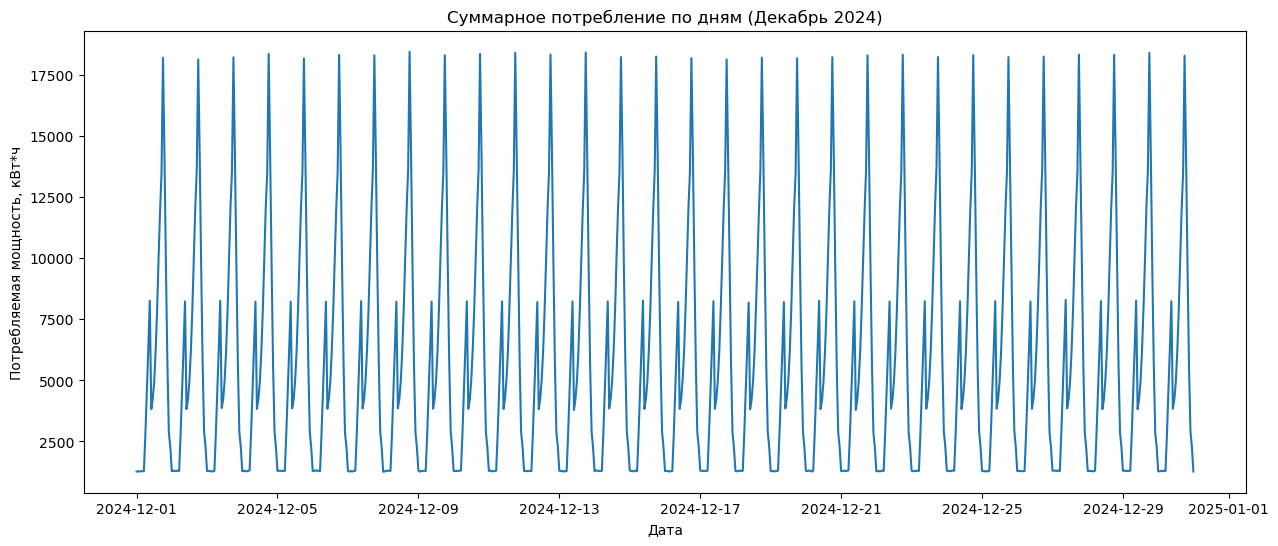

In [289]:
Consumption_by_day = Users_consumption.groupby(Users_consumption.time).agg({'power': 'sum'}).reset_index()

plt.figure(figsize=(15,6))
plt.plot(Consumption_by_day['time'], Consumption_by_day['power'])
plt.title('Суммарное потребление по дням (Декабрь 2024)')
plt.xlabel('Дата')
plt.ylabel('Потребляемая мощность, кВт*ч')
plt.show()

In [290]:
Users_streets_consumption = Users_consumption.groupby(['street'])['power'].agg('sum').reset_index().sort_values(by='power', ascending=False)

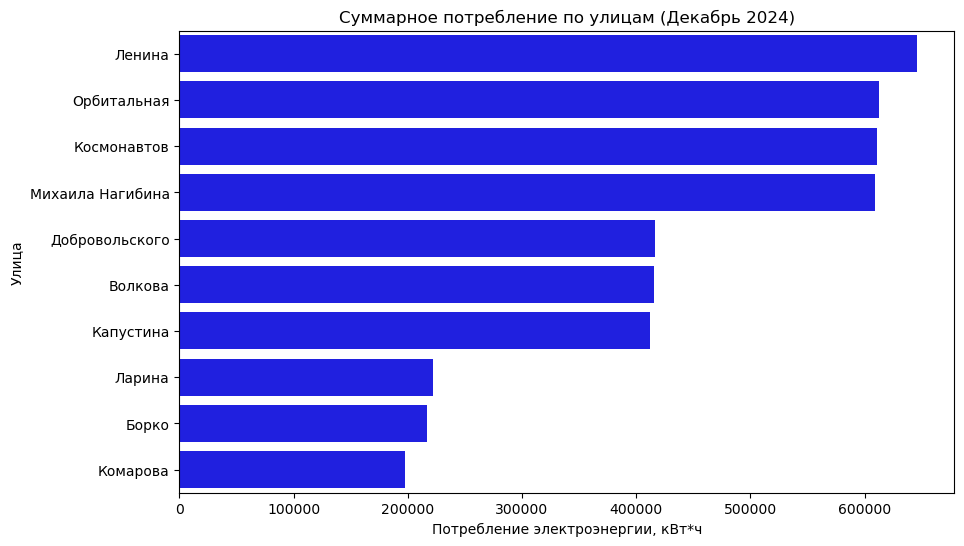

In [291]:
plt.figure(figsize=(10,6))

sns.barplot(data = Users_streets_consumption, x = 'power', y='street', color='blue')

plt.xlabel('Потребление электроэнергии, кВт*ч')
plt.ylabel('Улица')
plt.title('Суммарное потребление по улицам (Декабрь 2024)')

plt.show()

In [292]:
Users_electrician_meter = pd.merge(Users_Rostov_on_Don, Electrician_meter, left_on='electrician_meter_type', right_on='number', how='left')
Users_electrician_meter

,user,street,house,electrician_meter_type,date_connection,number,name,numbers_phase,current,voltage,year_production,verification_interval
0,1,Добровольского,76,6,2023-09-28,6,Меркурий AR 03 R,Трехфазный,7.5,400,2019,10
1,2,Волкова,60,10,2021-03-04,10,Меркурий 231 АМ-01,Трехфазный,5.0,380,2020,10
2,3,Борко,8,6,2019-12-20,6,Меркурий AR 03 R,Трехфазный,7.5,400,2019,10
3,4,Ларина,15,3,2020-01-07,3,АГАТ 1-1,Однофазный,5.0,230,2012,16
4,5,Михаила Нагибина,146,8,2013-09-05,8,Меркурий 231 AMш,Трехфазный,7.5,400,2012,12
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Добровольского,65,5,2011-07-14,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10
4996,4997,Ленина,147,2,2015-01-15,2,Меркурий 201.7,Однофазный,10.0,230,2012,12
4997,4998,Михаила Нагибина,97,5,2010-08-12,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10
4998,4999,Ленина,83,8,2014-03-11,8,Меркурий 231 AMш,Трехфазный,7.5,400,2012,12


In [293]:
year = (Users_electrician_meter.date_connection.dt.year + Users_electrician_meter.verification_interval).astype(str)
month = Users_electrician_meter.date_connection.dt.month.astype(str)
day = Users_electrician_meter.date_connection.dt.day.astype(str)

Users_electrician_meter['verification_date'] = Users_electrician_meter.apply(lambda row: row['date_connection'] + pd.DateOffset(years=row['verification_interval']), axis = 1)

Users_expired_verification_interval = Users_electrician_meter[Users_electrician_meter.verification_date <= datetime.now()]
Users_expired_verification_interval

,user,street,house,electrician_meter_type,date_connection,number,name,numbers_phase,current,voltage,year_production,verification_interval,verification_date
7,8,Ленина,82,2,2012-09-15,2,Меркурий 201.7,Однофазный,10.0,230,2012,12,2024-09-15
18,19,Комарова,18,8,2012-10-13,8,Меркурий 231 AMш,Трехфазный,7.5,400,2012,12,2024-10-13
22,23,Ларина,45,5,2014-04-25,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10,2024-04-25
27,28,Борко,39,5,2010-08-24,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10,2020-08-24
32,33,Ленина,84,2,2012-11-14,2,Меркурий 201.7,Однофазный,10.0,230,2012,12,2024-11-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4979,4980,Ленина,77,5,2013-12-16,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10,2023-12-16
4982,4983,Михаила Нагибина,102,5,2014-02-26,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10,2024-02-26
4986,4987,Ленина,51,5,2010-01-13,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10,2020-01-13
4995,4996,Добровольского,65,5,2011-07-14,5,Меркурий АМ-01,Однофазный,5.0,230,2008,10,2021-07-14


In [294]:
Count_electrician_meter_by_streets = Users_Rostov_on_Don.groupby(['street'], as_index=False) \
                                                        .size() \
                                                        .rename(columns={'size': 'count_electrician_meter'}) \
                                                        .sort_values(by='count_electrician_meter', ascending=False)

In [295]:
Count_expired_verification_interval_by_streets = Users_expired_verification_interval.groupby(['street'], as_index=False) \
                                                                                    .size() \
                                                                                    .rename(columns={'size': 'count_expired_electrician_meter'}) \
                                                                                    .sort_values(by='count_expired_electrician_meter', ascending=False)

In [296]:
Electrician_meter_by_streets = pd.merge(Count_electrician_meter_by_streets, Count_expired_verification_interval_by_streets, on = 'street', how = 'left')

In [297]:
Electrician_meter_by_streets['percent_expired_verification'] = round((Electrician_meter_by_streets['count_expired_electrician_meter'] * 100) 
                                                                     / Electrician_meter_by_streets['count_electrician_meter'], 2)
Electrician_meter_by_streets

,street,count_electrician_meter,count_expired_electrician_meter,percent_expired_verification
0,Ленина,744,109,14.65
1,Космонавтов,701,103,14.69
2,Орбитальная,701,117,16.69
3,Михаила Нагибина,692,107,15.46
4,Капустина,484,67,13.84
5,Добровольского,482,69,14.32
6,Волкова,476,61,12.82
7,Ларина,247,42,17.00
8,Борко,246,33,13.41
9,Комарова,227,33,14.54


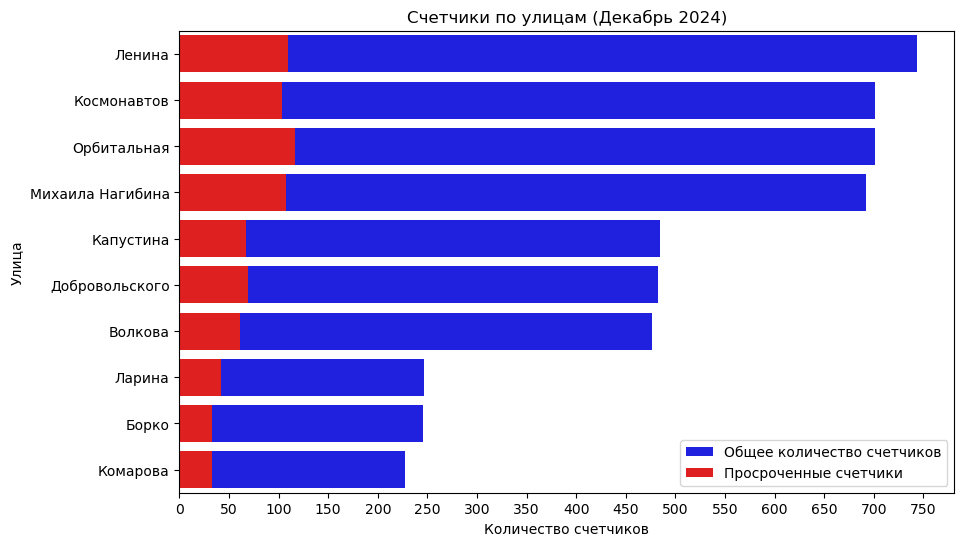

In [298]:
fig, ax = plt.subplots()

fig.set_figheight(6)
fig.set_figwidth(10)

sns.barplot(data = Electrician_meter_by_streets, x='count_electrician_meter', y='street', color='blue', label='Общее количество счетчиков')
sns.barplot(data = Electrician_meter_by_streets, x='count_expired_electrician_meter', y='street', color='red', label='Просроченные счетчики')

plt.title('Счетчики по улицам (Декабрь 2024)')
plt.xlabel('Количество счетчиков')
plt.ylabel('Улица')

ax.xaxis.set_major_locator(ticker.MultipleLocator(50))


plt.show()

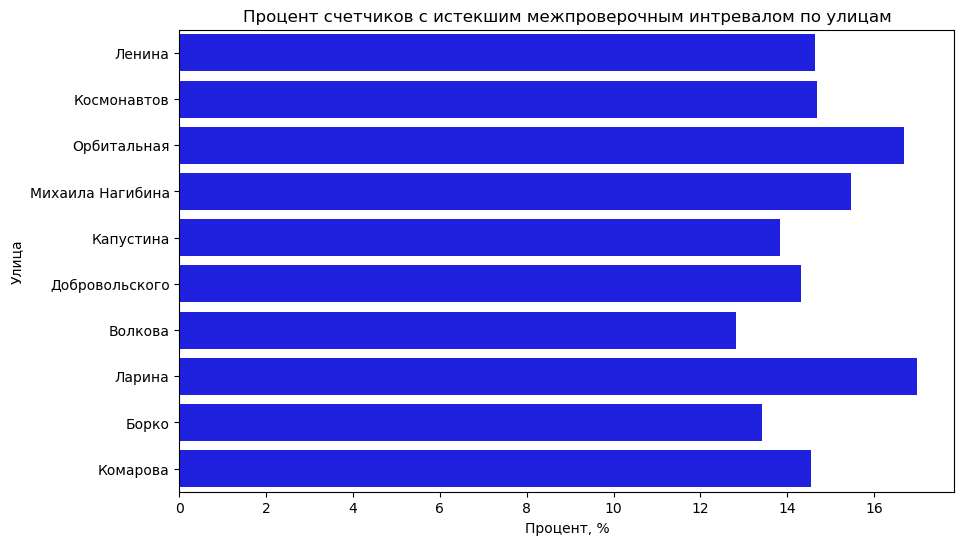

In [299]:
plt.figure(figsize=(10,6))

sns.barplot(data=Electrician_meter_by_streets, x='percent_expired_verification', y='street', color='blue')

plt.xlabel('Процент, %', loc='center')
plt.ylabel('Улица')
plt.title('Процент счетчиков с истекшим межпроверочным интревалом по улицам')

plt.show()

In [300]:
Consumption_by_hour = Users_consumption.groupby(Users_consumption.time.dt.hour).agg({'power': 'sum'}).reset_index()

Text(0, 0.5, 'Потребление электроэнергии, кВт*ч')

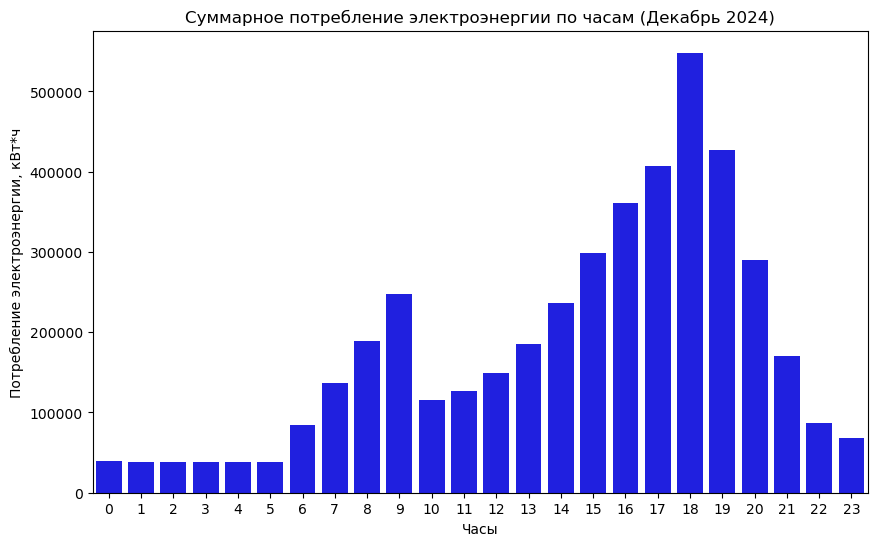

In [301]:
plt.figure(figsize=(10,6))

sns.barplot(data = Consumption_by_hour, x='time', y='power', color='blue')

plt.title('Суммарное потребление электроэнергии по часам (Декабрь 2024)')
plt.xlabel('Часы')
plt.ylabel('Потребление электроэнергии, кВт*ч')

In [302]:
max_street = Users_streets_consumption.street.tolist()[0]
min_street = Users_streets_consumption.street.tolist()[-1]

Street_with_max_consumption_by_hour = Users_consumption[Users_consumption.street == max_street].groupby(Users_consumption.time.dt.hour) \
                                                                                               .agg({'power': 'sum'}) \
                                                                                               .reset_index()

Street_with_min_consumption_by_hour = Users_consumption[Users_consumption.street == min_street].groupby(Users_consumption.time.dt.hour) \
                                                                                               .agg({'power': 'sum'}) \
                                                                                               .reset_index()

Text(0, 0.5, 'Потребление электроэнергии, кВт*ч')

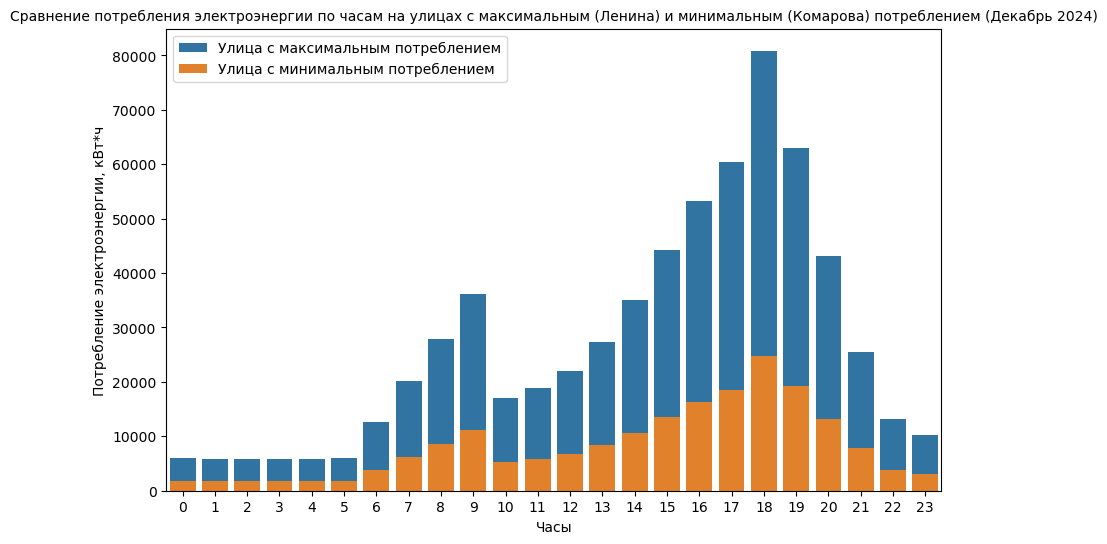

In [303]:
plt.figure(figsize=(10,6))

sns.barplot(data = Street_with_max_consumption_by_hour, x='time', y='power', label='Улица с максимальным потреблением')
sns.barplot(data = Street_with_min_consumption_by_hour, x='time', y='power', label='Улица с минимальным потреблением')

plt.legend()
plt.title(f'Сравнение потребления электроэнергии по часам на улицах с максимальным ({max_street}) и минимальным ({min_street}) потреблением (Декабрь 2024)', size=10)
plt.xlabel('Часы')
plt.ylabel('Потребление электроэнергии, кВт*ч')


In [304]:
Consuption_per_user = Users_consumption.groupby('user', as_index=False).agg({'power': 'sum'})
Consuption_per_user.describe()

,user,power
count,5000.000000,5000.000000
mean,2500.500000,871.769471
std,1443.520003,287.134806
min,1.000000,58.101234
25%,1250.750000,678.174155
50%,2500.500000,866.085491
75%,3750.250000,1062.024988
max,5000.000000,2260.472077


In [305]:
Users_consumption_mean_by_hour = Users_consumption.groupby(Users_consumption.time.dt.hour) \
                                                  .agg({'power': 'mean'})

In [306]:
procentile_95 = Consuption_per_user.power.quantile(0.95)
procentile_95

1351.2206396203346

In [307]:
procentile_05 = Consuption_per_user.power.quantile(0.05)
procentile_05

401.31444669300873

In [308]:
Consuption_per_user_percentile_95 = Consuption_per_user[Consuption_per_user.power > procentile_95]

In [309]:
Consuption_per_user_percentile_05 = Consuption_per_user[Consuption_per_user.power < procentile_05]

In [310]:
Users_consumption_percentile_95 = Users_consumption[Users_consumption['user'].isin(Consuption_per_user_percentile_95.user)]

Users_consumption_percentile_95_by_hour = Users_consumption_percentile_95.groupby(Users_consumption_percentile_95.time.dt.hour) \
                                                                         .agg({'power': 'mean'})

In [311]:
Users_consumption_percentile_05 = Users_consumption[Users_consumption['user'].isin(Consuption_per_user_percentile_05.user)]

Users_consumption_percentile_05_by_hour = Users_consumption_percentile_05.groupby(Users_consumption_percentile_05.time.dt.hour) \
                                                                         .agg({'power': 'mean'})

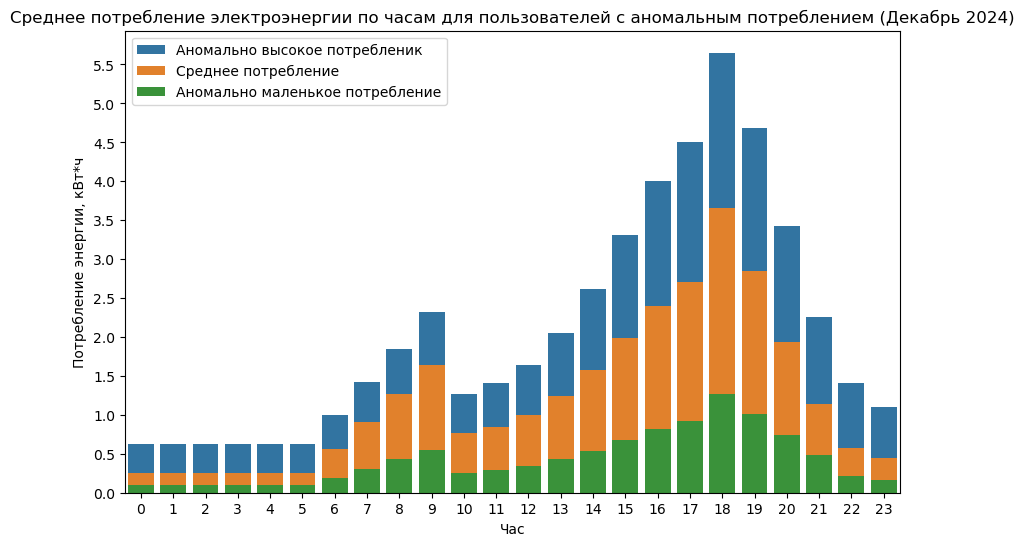

In [312]:
fig, ax = plt.subplots()

fig.set_figheight(6)
fig.set_figwidth(10)

sns.barplot(data=Users_consumption_percentile_95_by_hour, x='time', y='power', label='Аномально высокое потребленик')
sns.barplot(data=Users_consumption_mean_by_hour, x='time', y='power', label='Среднее потребление')
sns.barplot(data=Users_consumption_percentile_05_by_hour, x='time', y='power', label='Аномально маленькое потребление')

ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))

plt.title('Среднее потребление электроэнергии по часам для пользователей c аномальным потреблением (Декабрь 2024)')
plt.xlabel('Час')
plt.ylabel('Потребление энергии, кВт*ч')
plt.legend()
plt.show()

In [313]:
One_phase_consumption = Users_consumption[Users_consumption.electrician_meter_type.isin(Electrician_meter[Electrician_meter.numbers_phase == 'Однофазный'].number)]

One_phase_consumption = One_phase_consumption.merge(Electrician_meter[['number', 'name', 'year_production']], left_on='electrician_meter_type', right_on='number', how='left')

One_phase_consumption.rename(columns={'name': 'electrician_meter_name'}, inplace=True)

One_phase_consumption.drop(columns=['number'], inplace=True)

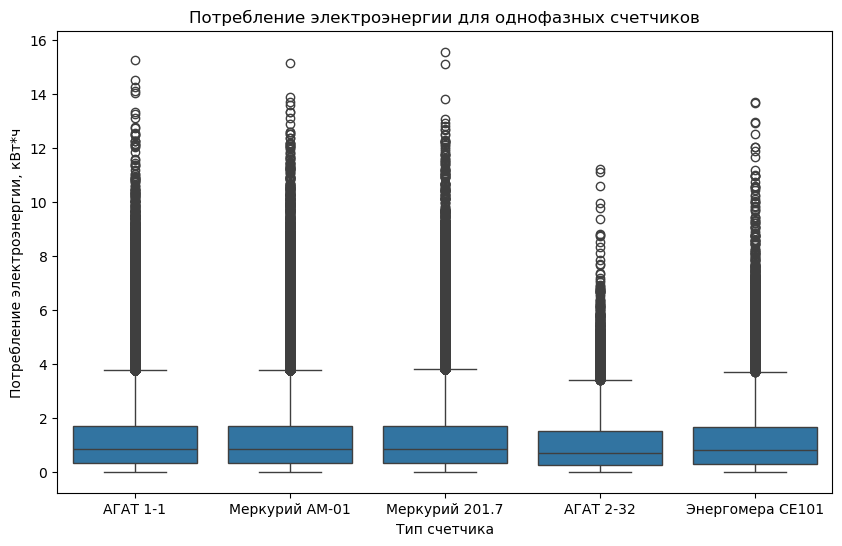

In [314]:
plt.figure(figsize=(10,6))

sns.boxplot(data=One_phase_consumption, x='electrician_meter_name', y='power')
plt.xlabel('Тип счетчика')
plt.ylabel('Потребление электроэнергии, кВт*ч')
plt.title('Потребление электроэнергии для однофазных счетчиков')
plt.show()

In [315]:
Three_phase_consumption = Users_consumption[Users_consumption.electrician_meter_type.isin(Electrician_meter[Electrician_meter.numbers_phase == 'Трехфазный'].number)]

Three_phase_consumption = Three_phase_consumption.merge(Electrician_meter[['number', 'name', 'year_production']], left_on='electrician_meter_type', right_on='number', how='left')

Three_phase_consumption.rename(columns={'name': 'electrician_meter_name'}, inplace=True)

Three_phase_consumption.drop(columns=['number'], inplace=True)

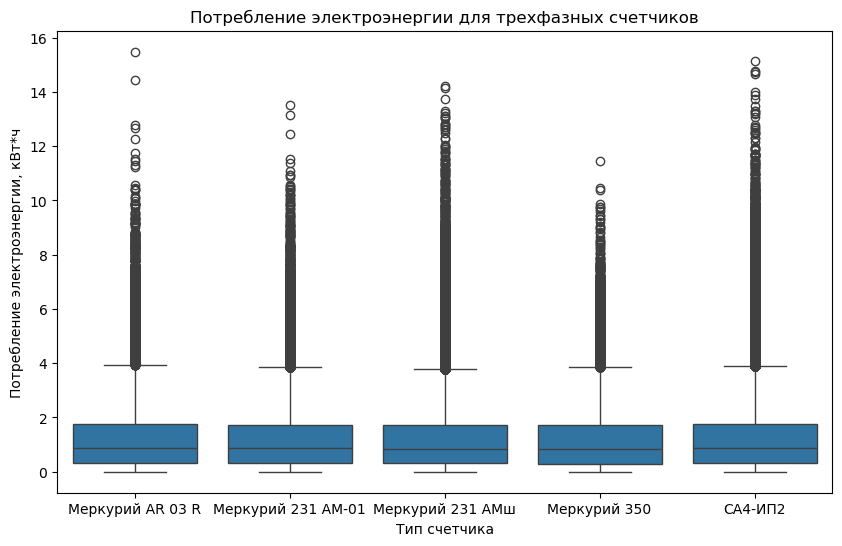

In [316]:
plt.figure(figsize=(10,6))

sns.boxplot(data=Three_phase_consumption, x='electrician_meter_name', y='power')
plt.xlabel('Тип счетчика')
plt.ylabel('Потребление электроэнергии, кВт*ч')
plt.title('Потребление электроэнергии для трехфазных счетчиков')
plt.show()

In [317]:
One_phase_consumption_by_year = One_phase_consumption.groupby('year_production', as_index=False).agg({'power': 'mean'})

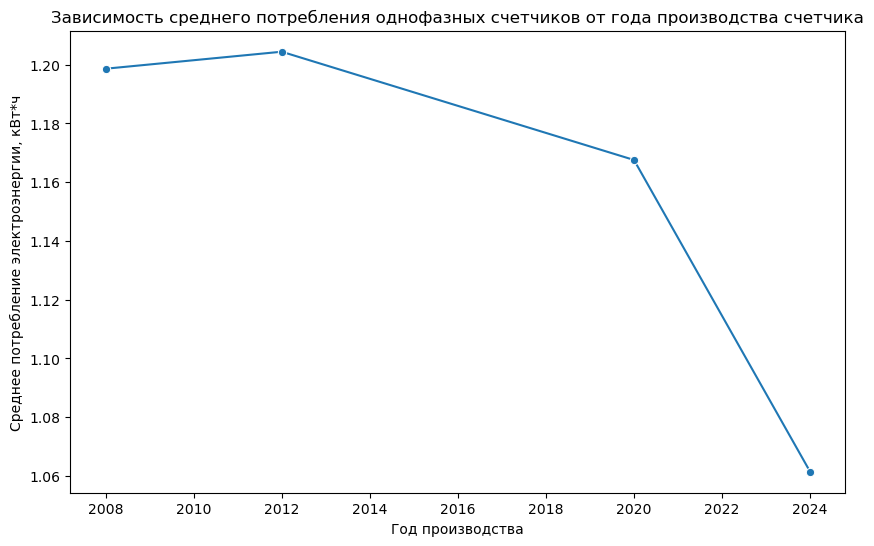

In [318]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=One_phase_consumption_by_year, x='year_production', y='power', marker='o')

plt.title('Зависимость среднего потребления однофазных счетчиков от года производства счетчика')
plt.xlabel('Год производства')
plt.ylabel('Среднее потребление электроэнергии, кВт*ч')

plt.show()

In [319]:
Three_phase_consumption_by_year = Three_phase_consumption.groupby('year_production', as_index=False).agg({'power': 'mean'})

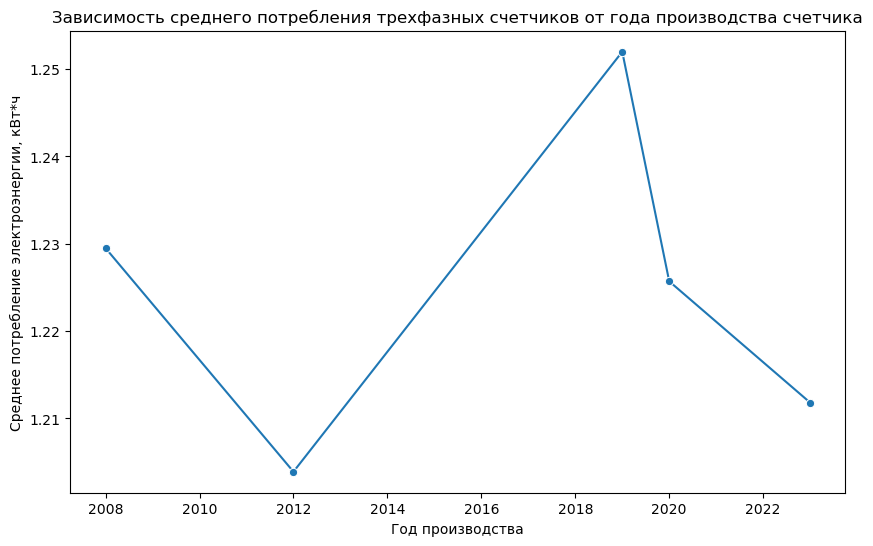

In [320]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=Three_phase_consumption_by_year, x='year_production', y='power', marker='o')

plt.title('Зависимость среднего потребления трехфазных счетчиков от года производства счетчика')
plt.xlabel('Год производства')
plt.ylabel('Среднее потребление электроэнергии, кВт*ч')

plt.show()

In [321]:
correlation_data = Users_consumption[['street','power']].copy()
correlation_data['street'] = correlation_data['street'].astype('category').cat.codes
corr = correlation_data['street'].corr(correlation_data.power)
print(f"Коэффициент корреляции между улицей и потреблением электроэнергии: {corr:.2f}")

Коэффициент корреляции между улицей и потреблением электроэнергии: 0.00


In [322]:
correlation_data = One_phase_consumption[['electrician_meter_type','power']].copy()
corr = correlation_data['electrician_meter_type'].corr(correlation_data.power)
print(f"Коэффициент корреляции между типом однофазного счетчика и потреблением электроэнергии: {corr:.2f}")

Коэффициент корреляции между типом однофазного счетчика и потреблением электроэнергии: -0.00


In [323]:
correlation_data = Three_phase_consumption[['electrician_meter_type','power']].copy()
corr = correlation_data['electrician_meter_type'].corr(correlation_data.power)
print(f"Коэффициент корреляции между типом трехфазного счетчика и потреблением электроэнергии: {corr:.2f}")

Коэффициент корреляции между типом трехфазного счетчика и потреблением электроэнергии: -0.00


In [342]:
sample_max_data = Users_consumption[Users_consumption.street == max_street]['power']
sample_min_data = Users_consumption[Users_consumption.street == min_street]['power']

# Вычисляем t-статистику и p-значение
t_stat, p_value = st.ttest_ind(sample_max_data, sample_min_data)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-значение: {p_value:.3f}")
alpha = 0.05
if p_value < alpha:
    print("Различие между средним потреблением улицы с максимальным суммарным и минимальным потреблением статистически значимо.")
else:
    print("Различие между средним потреблением улицы с максимальным суммарным и минимальным потреблением статистически не значимо.")

t-статистика: -0.620
p-значение: 0.535
Различие между средним потреблением улицы с максимальным суммарным и минимальным потреблением статистически не значимо.
